In [2]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

def coin():
    x = random.random()
    if x > 0.5:
        return 'O'
    else:
        return 'R'
    
def game(func = coin):
    seq = '000'
    while True:
        r = func()
        seq = seq[1:] + r
        if seq == 'ORR':
            seq = '000'
            return True
        if seq == 'OOR':
            seq = '000'
            return False

Zadanie 1.1
Grześ i Jaś rzucają monetą do momentu, aż w trzech ostatnich rzutach pojawi
się sekwencja OOR (wygrywa Jaś) lub ORR (wygrywa Grześ). 
(a) Oblicz dokładne prawdopodobieństwo zwycięstwa Grzesia.
(b) Oszacuj symulacyjnie prawdopodobieństwo zwycięstwa Grzesia.

In [3]:
def zadanie_1():
    n = 100000
    win = 0
    for i in range(n):
        if(game()) == True:
            win += 1
    print (f'Szansa na zwycięstwo Grzegorza wynosi: {win/n}')
zadanie_1()

Szansa na zwycięstwo Grzegorza wynosi: 0.33519


Zadanie 1.2
Grześ ma 25 bitcoinów, a Jaś 5 bitcoinów. W każdej rozgrywce stawiają po 1
bitcoinie i grają do momentu, gdy jeden z nich zbankrutuje. Oszacuj prawdopodobieństwo
bankructwa Grzesia.

In [4]:
n = 10000
win = 0

def betting(a, b):
    while True:
        if a == 0:
            return 0
        if b == 0:
            return 1
        if game() == True:
            a += 1
            b -= 1
        else:
            a -= 1
            b += 1
    
for i in range(n):
    G = 25
    J = 5
    win += betting(G, J)
print(f'Prawdopodobieństwo bankructwa Grzegorza wynosi: {1 - win / n}')

Prawdopodobieństwo bankructwa Grzegorza wynosi: 0.9705


Zadanie 1.3
Narysuj wykres prawdopodobieństwa bankructwa Jasia i Grzesia w zależności
od kapitałów początkowych (zakładając, że drugi gracz ma 10 bitcoinów).

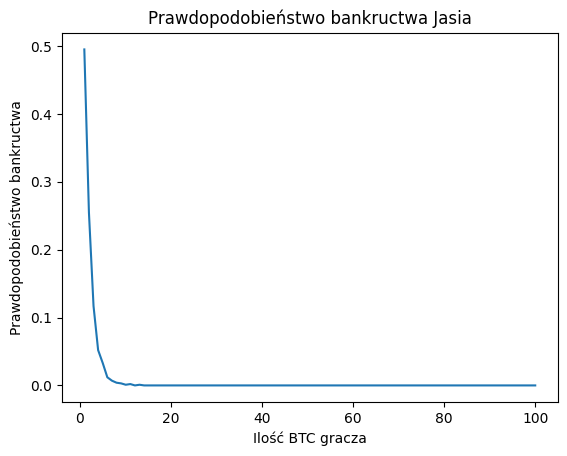

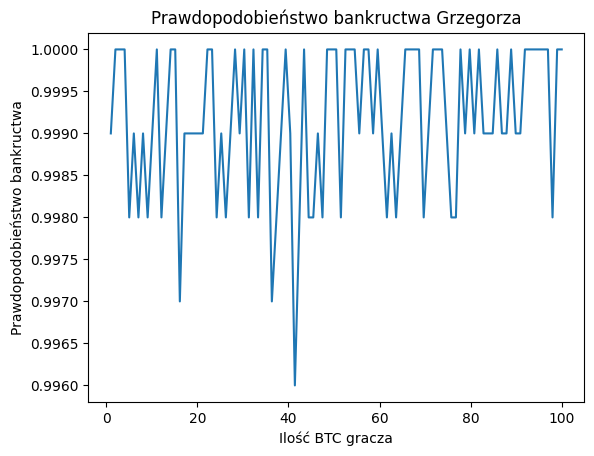

In [5]:
n = 1000
max_capital = 100
J_bankrupts = []
G_bankrupts = []

for capital in range(1, max_capital):
    bankrupcy_j = 0
    bankrupcy_g = 0
    for _ in range(n):
        bankrupcy_j += betting(10, capital)
        bankrupcy_g += betting(capital, 10)
    bankrupcy_g /= n
    bankrupcy_j /= n
    J_bankrupts.append(bankrupcy_j)
    G_bankrupts.append(1 - bankrupcy_g)

x = np.linspace(1,100,99)
plt.plot(x, J_bankrupts)
plt.title('Prawdopodobieństwo bankructwa Jasia')
plt.xlabel('Ilość BTC gracza')
plt.ylabel('Prawdopodobieństwo bankructwa')
plt.show()
plt.title('Prawdopodobieństwo bankructwa Grzegorza')
plt.xlabel('Ilość BTC gracza')
plt.ylabel('Prawdopodobieństwo bankructwa')
plt.plot(x, G_bankrupts)
plt.show()

Zadanie 1.4
Do gry dołącza Tosia z 50 bitcoinami i sekwencją RRR. Oblicz prawdopodobieństwo
zwycięstwa i bankructwa każdego z graczy. Czy da się dobrać kapitały
początkowe tak, aby wszyscy gracze mieli identyczne szanse na przegraną?

In [6]:
wins = [0, 0, 0]
N = 100
def game_with_Tosia(p1, p2, p3):
    seq = '000'
    while True:
        r = coin()
        seq = seq[1:] + r
        if seq == 'ORR' and p1:
            if p2 and p3:
                return [2, -1, -1]
            elif p2 and not p3:
                return [1, -1, 0]
            else:
                return [1, 0, -1]
            
        if seq == 'OOR' and p2:
            if p1 and p3:
                return [-1, 2, -1]
            elif p1 and not p3:
                return [-1, 1, 0]
            else:
                return [0, 1, -1]
            
        if seq == 'RRR' and p3:
            if p1 and p2:
                return [-1, -1, 2]
            elif p1 and not p2:
                return [-1, 0, 1]
            else:
                return [0, -1, 1]
        
def betting_with_Tosia(a, b, c):
    p1 = p2 = p3 = True
    while True:
        if a == 0:
            p1 = False
        if b == 0:
            p2 = False
        if c == 0:
            p3 = False

        if p1 == p2 == False:
            return [0, 0, 1]
        elif p1 == p3 == False:
            return [0, 1, 0]
        elif p2 == p3 == False:
            return [1, 0, 0]
        
        winner = game_with_Tosia(p1, p2, p3)
        a += winner[0]
        b += winner[1]
        c += winner[2]
        #print(a, b, c)
  
for p in range(N):
    G = 25
    J = 5
    T = 50
    result = betting_with_Tosia(G, J, T)
    for i in range(3):
        wins[i] += result[i]

print(wins)
print(f'Prawdodpodobieństwo zwycięstwa: {wins[0] / N, wins[1] / N, wins[2] / N}')
print(f'Prawdodpodobieństwo bankructwa: {1 - wins[0] / N, 1 - wins[1] / N, 1 - wins[2] / N}')


# próba zmiany kapitałów
K = 100
best_capital_ratio = [0, 0, 0, 1000]
best_win_ratio = [0,0,100]

for a in range(K):
    for b in range(K - a):
        c = K - a - b
        r = 0
        wins = [0, 0, 0]
        for _ in range(100):
            r = betting_with_Tosia(a, b, c)
            for i in range(3):
                wins[i] += r[i]

        spread = max(wins) - min(wins)

        if spread < best_capital_ratio[3]:
            best_capital_ratio = [a, b, c, spread]
            best_win_ratio = [wins[0], wins[1], wins[2]]
            print(best_capital_ratio, best_win_ratio)

print(f'Najlepszy rozkład prawdopodbieństwa dla: {best_capital_ratio} przy rozkładzie zwycięstw wynoszącym{best_win_ratio}')


[4, 96, 0]
Prawdodpodobieństwo zwycięstwa: (0.04, 0.96, 0.0)
Prawdodpodobieństwo bankructwa: (0.96, 0.040000000000000036, 1.0)
[0, 0, 100, 100] [0, 0, 100]
[0, 1, 99, 64] [0, 64, 36]
[1, 1, 98, 41] [31, 55, 14]
Najlepszy rozkład prawdopodbieństwa dla: [1, 1, 98, 41] przy rozkładzie zwycięstw wynoszącym[31, 55, 14]


Zadanie 1.5
Znajdź sekwencje początkowe dla dwóch graczy, które gwarantują sprawiedliwą
grę (identyczne prawdopodobieństwa wygranej).

Wygrywające sekwencje:
OOO, RRR;
OOR, RRO;
ORR, ROO;
ROR, ORO;

In [14]:
pairs = [['OOO', 'RRR'], ['OOR', 'RRO'], ['ROO', 'ORR'], ['ROR', 'ORO']]
def new_game(a,b,func = coin):
    seq = '000'
    while True:
        r = func()
        seq = seq[1:] + r
        if seq == a:
            seq = '000'
            return True
        if seq == b:
            seq = '000'
            return False

N = 100000
win = 0
for k in range(4):
    N = 100000
    win = 0
    for i in range(N):
        win += new_game(pairs[k][0], pairs[k][1])
    print(f'Sekwencja {pairs[k][0]} vs {pairs[k][1]}: {win / N}')

Sekwencja OOO vs RRR: 0.50389
Sekwencja OOR vs RRO: 0.49858
Sekwencja ROO vs ORR: 0.50475
Sekwencja ROR vs ORO: 0.49763


Zadanie 1.6
Grześ i Jaś rzucają niesymetryczną monetą, gdzie P(O) = po, P(R) = pr i
po + pr = 1. Napisz program oszacowujący, czy gra może być sprawiedliwa.
Narysuj wykres prawdopodobieństwa zwycięstwa Jasia w zależności od po.

Wysoka szansa na równość dla p0 = 37.0%
Wysoka szansa na równość dla p0 = 38.0%
Wysoka szansa na równość dla p0 = 39.0%


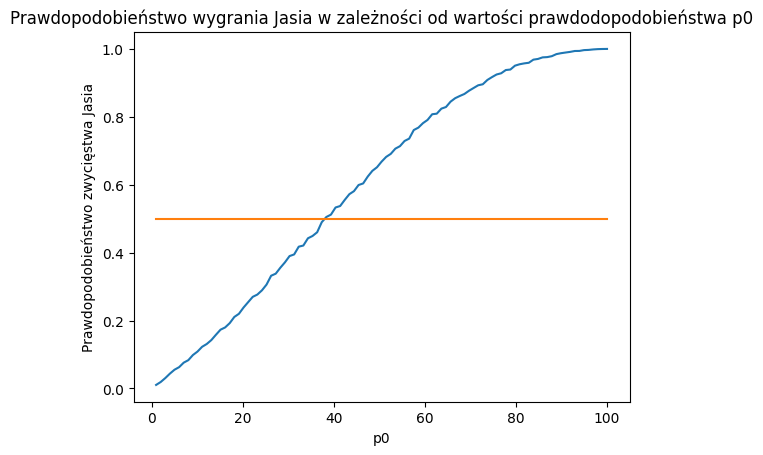

Prawdopodobieństwo dające najbardziej sprawiedliwą grę wynosi: 0.38303030303030305


In [15]:
def not_fair_coin(p0):
    x = random.random()
    if x < p0:
        return 'O'
    else:
        return 'R'
    
N = 10000
t = []
data = []

for i in range(1, 100):
    probability = i / 100
    win = 0
    for i in range(N):
        if(game(lambda: not_fair_coin(probability)) == True):
            win += 1
    data.append(1 - win / N)
    if abs(win / N - 1/2) < 0.02:
        t.append(probability)
        print(f'Wysoka szansa na równość dla p0 = {probability*100}%') 

plt.plot(np.linspace(1,100,99), data)
plt.title('Prawdopodobieństwo wygrania Jasia w zależności od wartości prawdodopodobieństwa p0')
plt.xlabel('p0')
plt.ylabel('Prawdopodobieństwo zwycięstwa Jasia')
plt.plot(np.linspace(1,100,99), [0.5]*99)
plt.show()

m = [t[0], 0.01] 
for i in t:
    X = np.linspace(0, 0.01, 100)
    for x in X:
        win = 0
        probability = i + x
        for _ in range(N):
            if(game(lambda: not_fair_coin(probability)) == True):
                win += 1
        if m[1] > abs(win/N - 1/2):
            m[0] = probability
            m[1] = abs(win/N - 1/2)
print(f'Prawdopodobieństwo dające najbardziej sprawiedliwą grę wynosi: {m[0]}')


Zadanie 2: Gry z kośćmi

In [16]:
def roll_dice():
    X = random.random()
    y = math.ceil(6*X)
    return y

In [17]:
def simulation():
    rolled = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}
    n = 0
    while 0 in rolled.values():
        n += 1
        roll = roll_dice()
        rolled[roll] += 1
    return n

N = 100000
count = 0
for i in range(N):
    count += simulation()

print(f'Oczekiwana liczba rzutów wynosi: {count / N}')

Oczekiwana liczba rzutów wynosi: 14.70161


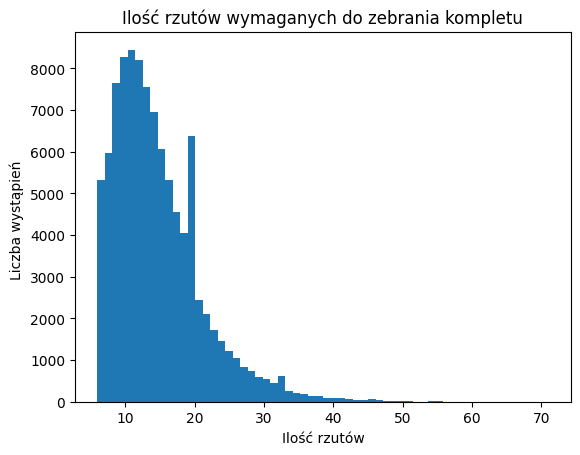

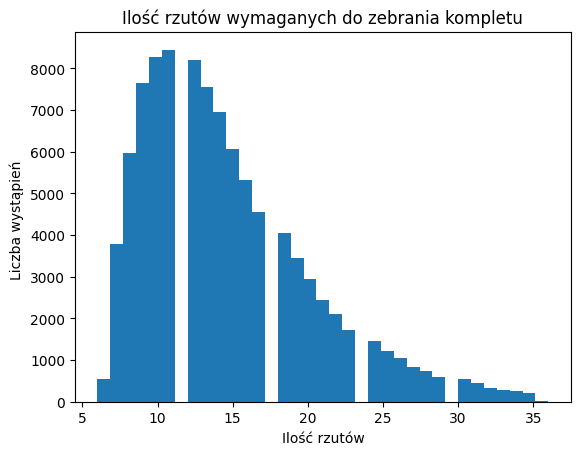

In [18]:
import scipy.stats

dice_rolls = []
N = 100000
for i in range(N):
    dice_rolls.append(simulation())
plt.hist(dice_rolls, bins=60)
plt.title('Ilość rzutów wymaganych do zebrania kompletu')
plt.xlabel('Ilość rzutów')
plt.ylabel('Liczba wystąpień ')
plt.show()

# jeżeli chcemy usunąć wartości skrajne
dice_rolls_new = scipy.stats.trimboth(dice_rolls, 0.01) # w parametrze dajemy jaki procent wartości skrajnych chcemy ususnąć
plt.hist(dice_rolls_new, bins = 35)
plt.title('Ilość rzutów wymaganych do zebrania kompletu')
plt.xlabel('Ilość rzutów')
plt.ylabel('Liczba wystąpień ')
plt.show()

Kto pierwszy wyrzuci szóstkę???


In [19]:
def game_six():
    while True:
        a = roll_dice()
        if a == 6:
            return True
        b = roll_dice()
        if b == 6:
            return False

def simulation():
    N = 100000
    win = 0
    for i in range(N):
        if game_six() == True:
            win += 1
    return win / N

print(f'Prawdopodobieństwo zwycięstwa gracza nr 1 wynosi: {simulation()}')

Prawdopodobieństwo zwycięstwa gracza nr 1 wynosi: 0.55007


Propozycja zamiany: w przypadku, gdy pierwszy gracz wylosuje 6stkę, gra się nie kończy - gracz nr 2 rzuca kostką i jeżeli trafi 6, to grają dalej

In [20]:
def new_game_six():
    while True:
        a = roll_dice()
        b = roll_dice()
        if a == 6 and b != 6:
            return True
        if b == 6 and a != 6:
            return False
        

def new_simulation():
    N = 100000
    win = 0
    for i in range(N):
        if new_game_six() == True:
            win += 1
    return win / N

print(f'Wynik po zmianie: {new_simulation()}')

Wynik po zmianie: 0.49919
